In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/content/predictive_maintenance.csv")

Part -**A**

Data Understanding


In [3]:
df.head(2)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure


In [4]:
df.shape

(10000, 10)

In [5]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Target,0
Failure Type,0


check null values

In [7]:
df.duplicated().sum()

np.int64(0)

checking duplicates


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [8]:
df.dtypes

df.nunique()

df.describe()

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Target,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0


Data Profiling


In [9]:
numerical_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

outlier analysis


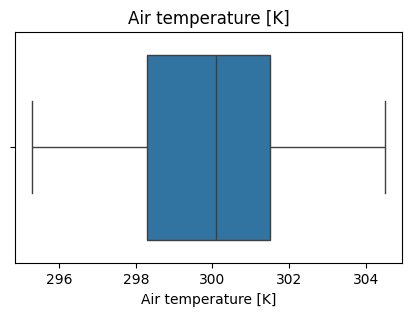

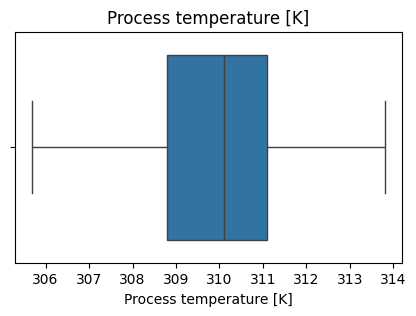

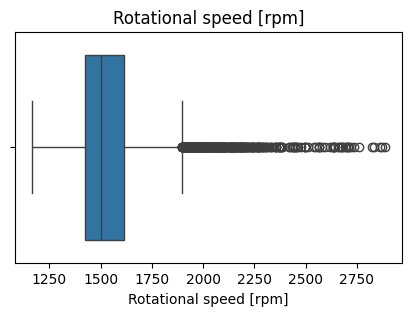

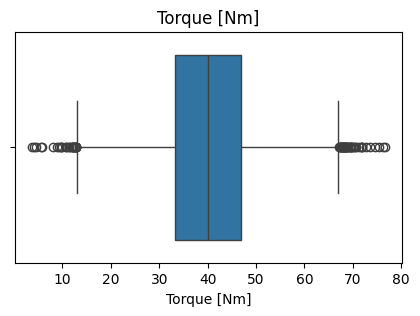

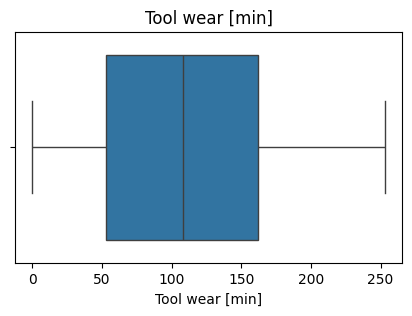

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [11]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df[col] < lower) |
    (df[col] > upper)
]

print(col, len(outliers))

Tool wear [min] 0


In [12]:
df = pd.get_dummies(
    df,
    columns=['Type'],
    drop_first=True
)

feature engineering


In [13]:
df['Temp_Difference'] = (
    df['Process temperature [K]']
    -
    df['Air temperature [K]']
)

In [14]:
df['Wear_Speed_Ratio'] = (
    df['Tool wear [min]']
    /
    df['Rotational speed [rpm]']
)

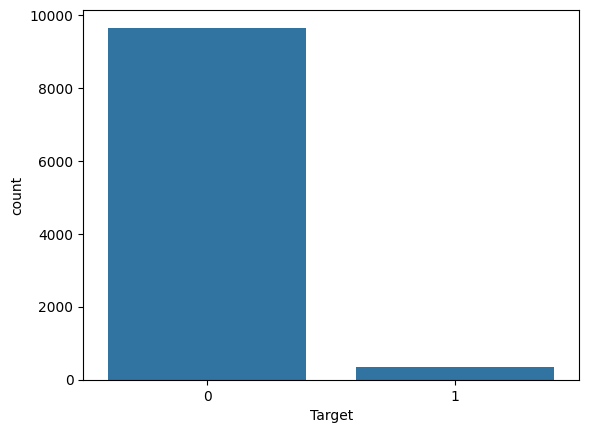

In [15]:
sns.countplot(
    x='Target',
    data=df
)
plt.show()

Most machines operate normally, while a smaller proportion experience failures

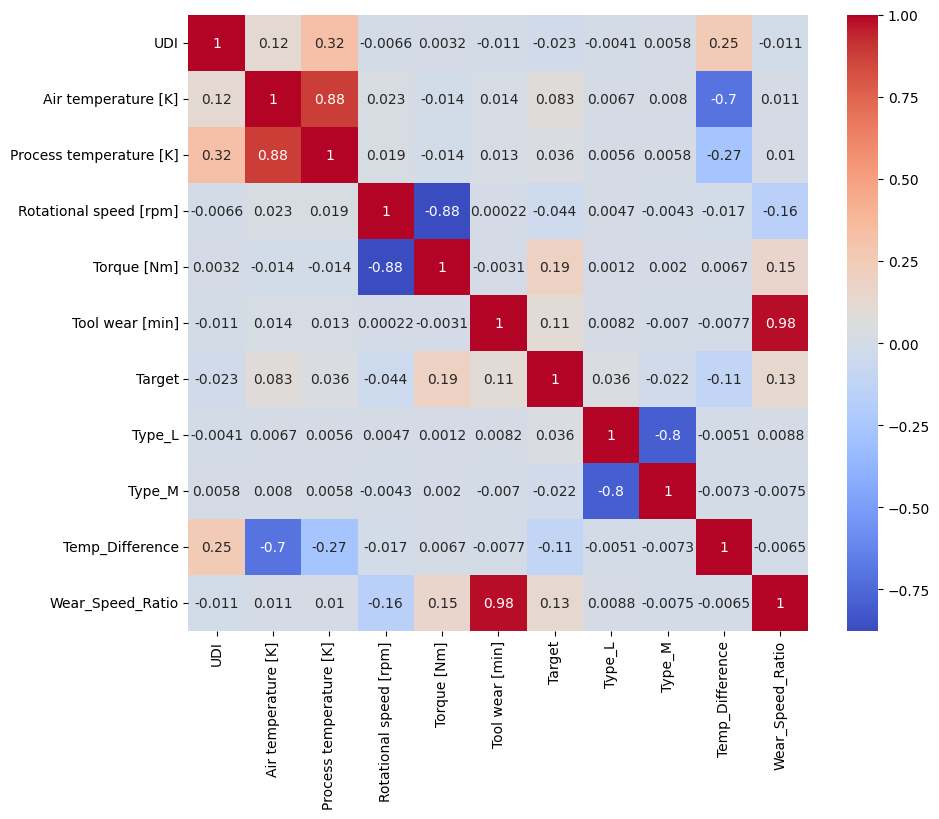

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

correaltion


Part-**B**

In [19]:
df.drop(
    ['UDI','Product ID','Failure Type'],
    axis=1,
    inplace=True
)

In [20]:
X = df.drop('Target', axis=1)

y = df['Target']

In [21]:
print(y.value_counts())

print(y.value_counts(normalize=True)*100)

Target
0    9661
1     339
Name: count, dtype: int64
Target
0    96.61
1     3.39
Name: proportion, dtype: float64


Data is Highly Imbalanced


Accuracy alone is useless.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)



In [26]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [27]:
y_pred = rf.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.988


In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.96      0.68      0.79        68

    accuracy                           0.99      2000
   macro avg       0.97      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



Lets try to improve recall
because recall is important in this

In [31]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

print(ratio)

28.52029520295203


In [33]:
X.columns = X.columns.str.replace('[', '', regex=False)
X.columns = X.columns.str.replace(']', '', regex=False)
X.columns = X.columns.str.replace('<', '', regex=False)
X.columns = X.columns.str.replace('>', '', regex=False)
X.columns = X.columns.str.replace(' ', '_')

In [34]:
print(X.columns)

Index(['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm',
       'Torque_Nm', 'Tool_wear_min', 'Type_L', 'Type_M', 'Temp_Difference',
       'Wear_Speed_Ratio'],
      dtype='object')


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
from xgboost import XGBClassifier

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_xgb
))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.65      0.81      0.72        68

    accuracy                           0.98      2000
   macro avg       0.82      0.90      0.86      2000
weighted avg       0.98      0.98      0.98      2000



For Predictive Maintenance, the business goal is:

Detect machines that are likely to fail.

Missing a failure is costly because:

Production stops
Downtime increases
Maintenance cost rises

Therefore:

✅ Recall is more important than Accuracy.


In [38]:
import pandas as pd

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Failure)',
        'Recall (Failure)',
        'F1-Score (Failure)'
    ],
    'Random Forest': [
        0.99,
        0.96,
        0.68,
        0.79
    ],
    'XGBoost': [
        0.98,
        0.65,
        0.81,
        0.72
    ]
})

print(comparison)

                Metric  Random Forest  XGBoost
0             Accuracy           0.99     0.98
1  Precision (Failure)           0.96     0.65
2     Recall (Failure)           0.68     0.81
3   F1-Score (Failure)           0.79     0.72


In [39]:
print("""
Conclusion:

Random Forest achieved higher accuracy (99%) and precision (96%)
but detected only 68% of actual failures.

XGBoost achieved a higher recall (81%), meaning it identified
more machines likely to fail.

Since predictive maintenance focuses on preventing equipment
breakdowns, Recall is more important than Accuracy.

Therefore, XGBoost was selected as the final model.
""")


Conclusion:

Random Forest achieved higher accuracy (99%) and precision (96%)
but detected only 68% of actual failures.

XGBoost achieved a higher recall (81%), meaning it identified
more machines likely to fail.

Since predictive maintenance focuses on preventing equipment
breakdowns, Recall is more important than Accuracy.

Therefore, XGBoost was selected as the final model.



1. What business problem was solved?

A predictive maintenance model was developed to identify machines likely to fail in advance, helping reduce downtime and maintenance costs.

2. Which variables influenced the outcome most?

The most important factors were:

Tool Wear
Torque
Rotational Speed
Process Temperature
Air Temperature
3. What insights were discovered?
Higher tool wear increases failure risk.
Abnormal torque and temperature conditions contribute to machine failures.
Machine failures can be predicted using sensor data.
4. What risks exist in deployment?
Sensor data errors.
Changes in operating conditions over time.
New machine types may affect model performance.
Some failures may still be missed.
5. What final recommendation would you provide to management?

Deploy the XGBoost model as an early warning system. Prioritize preventive maintenance for high-risk machines to reduce breakdowns, downtime, and maintenance costs while improving equipment reliability.